<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_07/lectures/lecture_7.1_py4dstem_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 7.1: Introduction to py4DSTEM Workflow

## Overview

This lecture introduces **4D-STEM** (four-dimensional scanning transmission electron microscopy) data analysis using the **py4DSTEM** Python package. We'll learn how to load, explore, and perform basic operations on 4D-STEM datasets.

## What is 4D-STEM?

**4D-STEM** records a 2D diffraction pattern at each position in a 2D scan:
- **Scan dimensions**: (x, y) - real space position
- **Detector dimensions**: (kx, ky) - reciprocal space (diffraction pattern)
- **Total dataset**: 4D array of shape (Rx, Ry, Qx, Qy)

### Key Advantages:
- **Complete information**: Full diffraction at every position
- **Flexible post-acquisition analysis**: Extract multiple signals
- **Quantitative measurements**: Strain, orientation, phase
- **High spatial resolution**: Nanometer-scale mapping

### Applications:
- Orientation mapping (virtual dark field)
- Strain and lattice parameter mapping
- Differential phase contrast (DPC) imaging
- Ptychographic phase reconstruction
- Electric/magnetic field mapping

## Learning Objectives

By the end of this lecture, you will:
1. Understand 4D-STEM data structure and dimensionality
2. Load and inspect 4D-STEM datasets with py4DSTEM
3. Navigate between real and reciprocal space
4. Perform basic operations: virtual imaging, beam position analysis
5. Understand metadata and calibration
6. Prepare data for advanced analysis workflows

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import h5py
import os

# Check for py4DSTEM
try:
    import py4DSTEM
    print(f"py4DSTEM version: {py4DSTEM.__version__}")
except ImportError:
    print("py4DSTEM not installed. Install with: pip install py4DSTEM")
    print("For this tutorial, we'll use alternative methods.")

print(f"NumPy version: {np.__version__}")
print(f"h5py version: {h5py.__version__}")

py4DSTEM version: 0.14.18
NumPy version: 2.2.6
h5py version: 3.15.1


## Part 1: Understanding 4D-STEM Data Structure

### Data Dimensionality

A 4D-STEM dataset has four dimensions:

```
datacube[scan_x, scan_y, detector_qx, detector_qy]
```

- **Scan dimensions (Rx, Ry)**: Real space - where the beam was positioned
- **Detector dimensions (Qx, Qy)**: Reciprocal space - diffraction pattern

Example: A 64×64 scan with 256×256 detector:
- Shape: (64, 64, 256, 256)
- Total size: ~4 GB (float32)

### Data Organization

**Real Space (Scan):**
```
Position (i, j) in scan → datacube[i, j, :, :]
```
Returns: Full diffraction pattern at that position

**Reciprocal Space (Detector):**
```
Pixel (u, v) in detector → datacube[:, :, u, v]
```
Returns: Image showing where specific diffraction feature appears

In [2]:
# Dataset information
data_dir = "/Users/robertoreis/Documents/codes/465_Computational_Microscopy_2026/data_4dstem/SmB6"
master_file = os.path.join(data_dir, "SmB6_10us_1kpx_HM_4_master.h5")

print(f"Dataset location: {data_dir}")
print(f"Master file: {os.path.basename(master_file)}")
print(f"File exists: {os.path.exists(master_file)}")

# List all data files
data_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.h5') and 'data_' in f])
print(f"\nNumber of data files: {len(data_files)}")
print(f"Data files: {', '.join(data_files[:3])} ... {data_files[-1]}")

Dataset location: /Users/robertoreis/Documents/codes/465_Computational_Microscopy_2026/data_4dstem/SmB6
Master file: SmB6_10us_1kpx_HM_4_master.h5
File exists: True

Number of data files: 10
Data files: SmB6_10us_1kpx_HM_4_data_000001.h5, SmB6_10us_1kpx_HM_4_data_000002.h5, SmB6_10us_1kpx_HM_4_data_000003.h5 ... SmB6_10us_1kpx_HM_4_data_000010.h5


## Part 2: Loading 4D-STEM Data

### HDF5 File Format

Most 4D-STEM data is stored in **HDF5** format (`.h5` files):
- Hierarchical structure (like nested folders)
- Efficient storage and access
- Supports metadata
- Can handle very large datasets

### Loading Strategy

For large datasets, we don't load everything at once:
1. **Inspect structure** first
2. **Load metadata** (scan size, calibration)
3. **Load subsets** or **memory-map** the full dataset
4. **Process in chunks** if needed

In [3]:
# Inspect master file structure
print("Exploring master file structure...\n")

with h5py.File(master_file, 'r') as f:
    def print_structure(name, obj):
        """Recursively print HDF5 structure"""
        indent = "  " * name.count('/')
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}{name}: Dataset {obj.shape} {obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}{name}: Group")
    
    print("HDF5 Structure:")
    print("-" * 60)
    f.visititems(print_structure)
    
    # Check for common 4D-STEM data paths
    print("\n" + "=" * 60)
    print("Checking for data arrays...")
    
    # Common paths in 4D-STEM files
    possible_paths = [
        '/entry/data/data',
        '/4DSTEM_experiment/data/datacube',
        '/data/datacube',
        '/datacube',
        '/data',
    ]
    
    for path in possible_paths:
        if path in f:
            data = f[path]
            print(f"\nFound data at: {path}")
            print(f"  Shape: {data.shape}")
            print(f"  Dtype: {data.dtype}")
            print(f"  Size: {data.size * data.dtype.itemsize / 1e9:.2f} GB")
            break
    else:
        print("\nData path not in common locations. Exploring...")
        # List all datasets
        datasets = []
        def find_datasets(name, obj):
            if isinstance(obj, h5py.Dataset) and len(obj.shape) == 4:
                datasets.append((name, obj.shape, obj.dtype))
        f.visititems(find_datasets)
        
        if datasets:
            print(f"\nFound {len(datasets)} 4D dataset(s):")
            for path, shape, dtype in datasets:
                print(f"  {path}: {shape} {dtype}")

Exploring master file structure...

HDF5 Structure:
------------------------------------------------------------
entry: Group
  entry/data: Group
  entry/definition: Dataset () |S5
  entry/instrument: Group
    entry/instrument/beam: Group
      entry/instrument/beam/incident_wavelength: Dataset () float64
    entry/instrument/detector: Group
      entry/instrument/detector/beam_center_x: Dataset () float64
      entry/instrument/detector/beam_center_y: Dataset () float64
      entry/instrument/detector/bit_depth_image: Dataset () uint16
      entry/instrument/detector/bit_depth_readout: Dataset () uint16
      entry/instrument/detector/count_time: Dataset () float64
      entry/instrument/detector/countrate_correction_applied: Dataset () int8
      entry/instrument/detector/description: Dataset () |S18
      entry/instrument/detector/detectorSpecific: Group
        entry/instrument/detector/detectorSpecific/auto_summation: Dataset () int8
        entry/instrument/detector/detectorSpec

## Part 3: Working with py4DSTEM DataCube

The **DataCube** object is the core data structure in py4DSTEM. It provides:
- Convenient access to data
- Metadata handling
- Calibration support
- Built-in visualization methods

### Loading with py4DSTEM

```python
# Standard loading
dataset = py4DSTEM.io.read(filepath)

# Memory-mapped loading (for large files)
dataset = py4DSTEM.io.read(filepath, mem='MEMMAP')
```

Since our data uses a multi-file format, we'll load it appropriately.

Loading Arina 4D-STEM dataset...
Master file: SmB6_10us_1kpx_HM_4_master.h5

Method 1: Using py4DSTEM.import_file for Arina format...
✓ Loaded successfully!
  DataCube shape: (1000, 1000, 96, 96)
  Scan shape (Rx, Ry): 1000 × 1000
  Detector shape (Qx, Qy): 96 × 96

Dataset Summary:
  Scan positions: 1000 × 1000 = 1000000 points
  Detector size: 96 × 96 pixels
  Total datacube: 9,216,000,000 elements
  Memory footprint: 18.43 GB

Computing mean diffraction pattern...
  Mean DP shape: (96, 96)
  Beam center (center of mass): (45.75, 45.06)


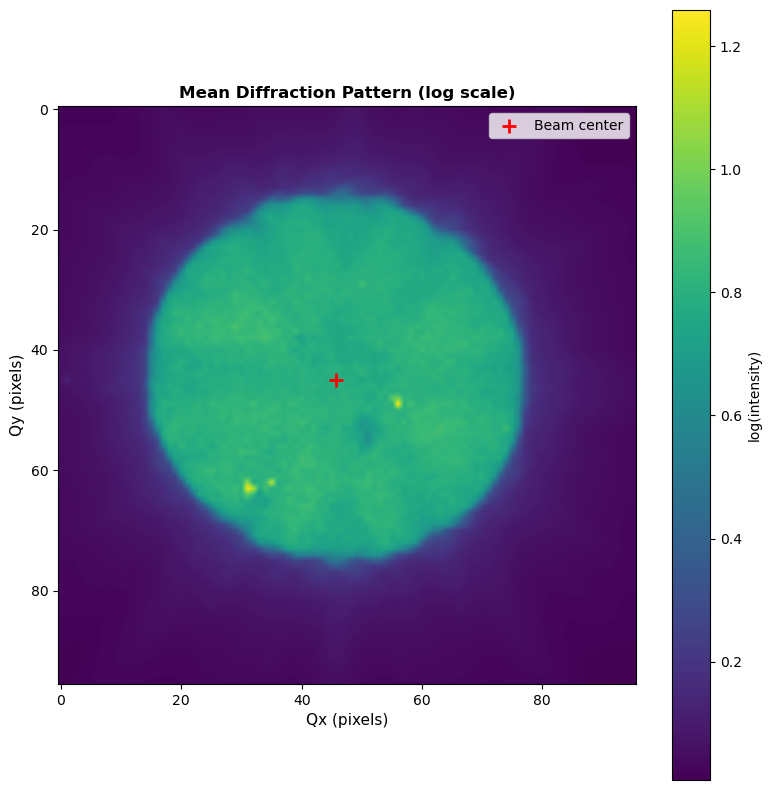

In [12]:
# Load 4D-STEM data (Arina format)
# Arina datasets use multi-file HDF5 format with a master file

print("Loading Arina 4D-STEM dataset...")
print(f"Master file: {os.path.basename(master_file)}\n")

try:
    # For Arina format, use py4DSTEM.import_file
    print("Method 1: Using py4DSTEM.import_file for Arina format...")
    datacube = py4DSTEM.import_file(master_file)
    
    # Extract data array
    if hasattr(datacube, 'data'):
        datacube_array = datacube.data
    else:
        datacube_array = np.array(datacube)
    
    print(f"✓ Loaded successfully!")
    print(f"  DataCube shape: {datacube_array.shape}")
    print(f"  Scan shape (Rx, Ry): {datacube_array.shape[0]} × {datacube_array.shape[1]}")
    print(f"  Detector shape (Qx, Qy): {datacube_array.shape[2]} × {datacube_array.shape[3]}")
    
except Exception as e:
    print(f"py4DSTEM import failed: {e}")
    print("\nMethod 2: Direct HDF5 loading for Arina format...")
    
    # For Arina: read master file to understand structure
    with h5py.File(master_file, 'r') as f:
        print("Master file structure:")
        for key in f.keys():
            print(f"  {key}: {type(f[key])}")
        
        # Arina typically has metadata here
        if 'entry' in f:
            print("\nMetadata (from 'entry'):")
            for attr_key in f['entry'].attrs:
                print(f"  @{attr_key}: {f['entry'].attrs[attr_key]}")
        
        # Find the 4D data
        data_path = None
        for key in f.keys():
            if isinstance(f[key], h5py.Group):
                for subkey in f[key].keys():
                    full_path = f"{key}/{subkey}"
                    if isinstance(f[full_path], h5py.Dataset):
                        if len(f[full_path].shape) == 4:
                            data_path = full_path
                            break
        
        if data_path:
            print(f"\nLoading from: {data_path}")
            # Memory-map for efficiency
            data = f[data_path]
            
            # Get shape info
            Rx, Ry, Qx, Qy = data.shape
            print(f"  Shape: ({Rx}, {Ry}, {Qx}, {Qy})")
            print(f"  Real space: {Rx} × {Ry}")
            print(f"  Reciprocal space: {Qx} × {Qy}")
            
            # For this tutorial, we'll load a manageable subset
            # To avoid memory issues, we can downsample or crop
            print("\nFor demonstration, loading a subset...")
            
            # Option 1: Load central region
            # r_slice = slice(Rx//4, 3*Rx//4)
            # q_slice = slice(Qx//4, 3*Qx//4)
            
            # Option 2: Load every Nth frame
            stride = 2
            datacube_array = data[::stride, ::stride, :, :]
            
            print(f"  Loaded shape: {datacube_array.shape}")
            print(f"  Memory: {datacube_array.nbytes / 1e9:.2f} GB")
        else:
            print("Could not find 4D data array in file")
            datacube_array = None

# Store metadata
if 'datacube_array' in locals() and datacube_array is not None:
    Rx, Ry, Qx, Qy = datacube_array.shape
    print(f"\n{'='*60}")
    print("Dataset Summary:")
    print(f"  Scan positions: {Rx} × {Ry} = {Rx*Ry} points")
    print(f"  Detector size: {Qx} × {Qy} pixels")
    print(f"  Total datacube: {datacube_array.size:,} elements")
    print(f"  Memory footprint: {datacube_array.nbytes / 1e9:.2f} GB")
    
    # Compute mean diffraction pattern
    print("\nComputing mean diffraction pattern...")
    mean_dp = np.mean(datacube_array, axis=(0, 1))
    
    # Find beam center using center of mass (more robust than finding max pixel)
    # Normalize the pattern for COM calculation
    mean_dp_normalized = mean_dp / np.max(mean_dp)
    
    # Compute center of mass
    Qy_idx, Qx_idx = np.ogrid[:mean_dp.shape[0], :mean_dp.shape[1]]
    center_x = np.sum(mean_dp_normalized * Qx_idx) / np.sum(mean_dp_normalized)
    center_y = np.sum(mean_dp_normalized * Qy_idx) / np.sum(mean_dp_normalized)
    
    print(f"  Mean DP shape: {mean_dp.shape}")
    print(f"  Beam center (center of mass): ({center_x:.2f}, {center_y:.2f})")
    
    # Visualize mean diffraction pattern
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    im = ax.imshow(np.log(mean_dp + 1), cmap='viridis', interpolation='bilinear')
    ax.scatter([center_x], [center_y], c='red', s=100, marker='+', linewidths=2, label='Beam center')
    ax.set_xlabel('Qx (pixels)', fontsize=11)
    ax.set_ylabel('Qy (pixels)', fontsize=11)
    ax.set_title('Mean Diffraction Pattern (log scale)', fontsize=12, weight='bold')
    ax.legend(fontsize=10)
    plt.colorbar(im, ax=ax, label='log(intensity)')
    plt.tight_layout()
    plt.show()

## Part 4: Exploring the Data

### Visualization Strategies

**1. Virtual Bright Field (VBF)**
- Sum intensity over central disk in each diffraction pattern
- Real-space image showing sample structure

**2. Mean Diffraction Pattern**
- Average of all diffraction patterns
- Shows common features across scan

**3. Maximum Diffraction Pattern**
- Maximum intensity at each Q-pixel
- Highlights all possible diffraction spots

**4. Single Position Diffraction**
- Diffraction pattern at chosen (x,y) position
- Examine local structure

## Part 5: Calibration and Metadata

### Important Calibration Parameters

For quantitative analysis, you need:

1. **Real space calibration** (nm/pixel or Å/pixel)
   - Scan step size
   - Depends on probe size and overlap
   
2. **Reciprocal space calibration** (1/Å per detector pixel or mrad/pixel)
   - Camera length
   - Detector pixel size
   - Wavelength/acceleration voltage

3. **Center position**
   - Direct beam position (Qx₀, Qy₀)
   - Critical for strain and DPC analysis

### Determining Calibration

**From metadata**: Check HDF5 file attributes

**From known reflections**: Measure pixel distance between known Bragg spots

**From HOLZ rings**: Higher-order Laue zone features

In [13]:
# Extract metadata from file
print("Searching for metadata...")

with h5py.File(master_file, 'r') as f:
    # Check attributes at different levels
    print("\n" + "="*60)
    print("File-level attributes:")
    for key, value in f.attrs.items():
        print(f"  {key}: {value}")
    
    # Check for calibration info in common locations
    calibration_paths = [
        '/entry/instrument',
        '/4DSTEM_experiment/metadata',
        '/metadata',
    ]
    
    print("\n" + "="*60)
    print("Searching for calibration data...")
    
    for path in calibration_paths:
        if path in f:
            print(f"\nFound: {path}")
            obj = f[path]
            if isinstance(obj, h5py.Group):
                for key in obj.keys():
                    item = obj[key]
                    if isinstance(item, h5py.Dataset):
                        print(f"  {key}: {item[()]}")
                    elif isinstance(item, h5py.Group):
                        print(f"  {key}: <Group>")
                for key, value in obj.attrs.items():
                    print(f"  @{key}: {value}")

# For this tutorial, we'll set typical calibration values
# These should be replaced with actual values from your experiment

# Typical values for 4D-STEM
print("\n" + "="*60)
print("Setting calibration parameters:")
print("(Replace with actual experimental values)")

# Real space (scan)
R_pixel_size_nm = 1.0  # nm/pixel (adjust based on your scan)
print(f"  Real space: {R_pixel_size_nm} nm/pixel")

# Reciprocal space (detector)
# This depends on camera length, wavelength, detector pixel size
# For 200 keV, camera length ~100 mm, detector pixel ~55 μm
wavelength_pm = 2.51  # pm (200 keV electrons)
camera_length_mm = 100  # mm
detector_pixel_um = 55  # μm

# Calibration: mrad per detector pixel
Q_pixel_size_mrad = (detector_pixel_um * 1e-3) / camera_length_mm * 1000
print(f"  Reciprocal space: {Q_pixel_size_mrad:.3f} mrad/pixel")

# Convert to 1/Å using small angle approximation
# q (1/Å) = θ (rad) / λ (Å)
Q_pixel_size_invA = (Q_pixel_size_mrad * 1e-3) / (wavelength_pm * 1e-2)
print(f"  Reciprocal space: {Q_pixel_size_invA:.4f} Å⁻¹/pixel")

# Beam center (direct beam position)
beam_center_x = center_x
beam_center_y = center_y
print(f"  Beam center: ({beam_center_x}, {beam_center_y})")

# Store in dictionary for later use
calibration = {
    'R_pixel_size_nm': R_pixel_size_nm,
    'Q_pixel_size_mrad': Q_pixel_size_mrad,
    'Q_pixel_size_invA': Q_pixel_size_invA,
    'beam_center': (beam_center_x, beam_center_y),
    'energy_keV': 200.0,
    'wavelength_pm': wavelength_pm,
}

print("\nCalibration dictionary created ✓")

Searching for metadata...

File-level attributes:
  default: b'entry'

Searching for calibration data...

Found: /entry/instrument
  beam: <Group>
  detector: <Group>
  @NX_class: b'NXinstrument'

Setting calibration parameters:
(Replace with actual experimental values)
  Real space: 1.0 nm/pixel
  Reciprocal space: 0.550 mrad/pixel
  Reciprocal space: 0.0219 Å⁻¹/pixel
  Beam center: (45.75265778443822, 45.05841000557568)

Calibration dictionary created ✓


## Part 6: Basic 4D-STEM Operations

### Virtual Imaging

**Virtual Bright Field (VBF)**: Integrate over direct beam

**Virtual Dark Field (VDF)**: Integrate over specific diffracted beams

**Virtual Annular Dark Field (VADF)**: Integrate over annular region

These are "virtual" because they're created post-acquisition, not during imaging.

### Advantages:
- Extract multiple images from single dataset
- Optimize aperture positions after acquisition
- Create images from specific features

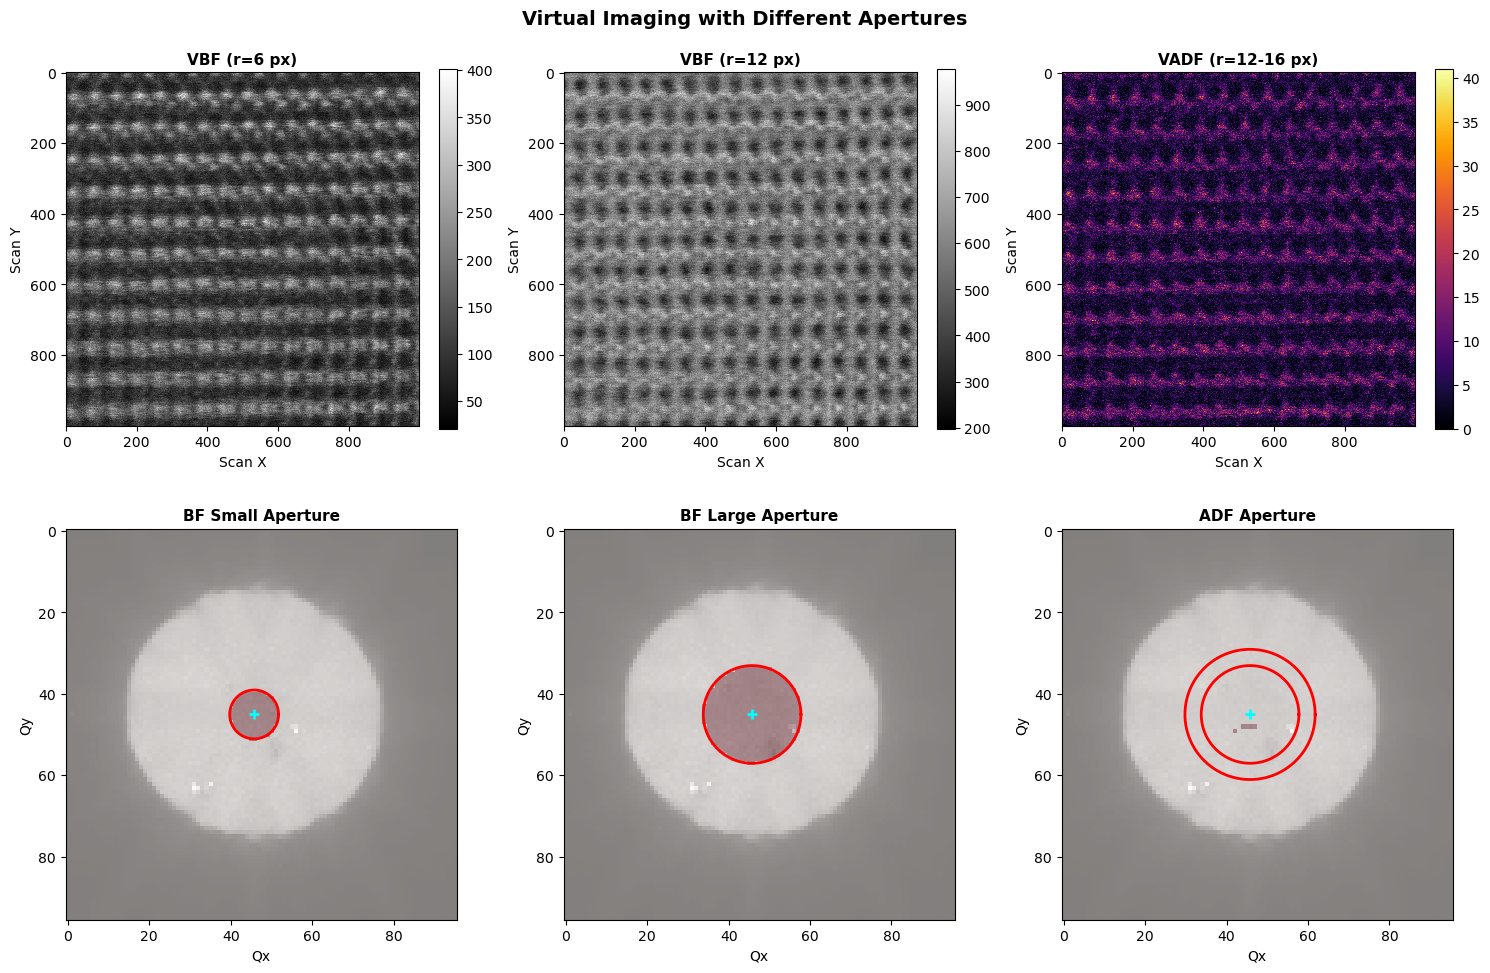


Virtual imaging complete!
  BF small (r=6): range 21.0 - 401.0
  BF large (r=12): range 198.0 - 977.0
  ADF: range 0.0 - 41.0


In [15]:
# Demonstrate virtual imaging with different apertures

if 'datacube_array' in locals() and datacube_array is not None:
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Parameters
    center_x, center_y = calibration['beam_center']
    
    # 1. Virtual Bright Field - small aperture
    radius_bf_small = Qx // 16
    Y, X = np.ogrid[:Qy, :Qx]
    mask_bf_small = (X - center_x)**2 + (Y - center_y)**2 <= radius_bf_small**2
    vbf_small = np.sum(datacube_array * mask_bf_small[np.newaxis, np.newaxis, :, :], axis=(2, 3))
    
    ax = axes[0, 0]
    im = ax.imshow(vbf_small, cmap='gray', interpolation='nearest')
    ax.set_title(f'VBF (r={radius_bf_small} px)', fontsize=11, weight='bold')
    ax.set_xlabel('Scan X')
    ax.set_ylabel('Scan Y')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # 2. Virtual Bright Field - large aperture
    radius_bf_large = Qx // 8
    mask_bf_large = (X - center_x)**2 + (Y - center_y)**2 <= radius_bf_large**2
    vbf_large = np.sum(datacube_array * mask_bf_large[np.newaxis, np.newaxis, :, :], axis=(2, 3))
    
    ax = axes[0, 1]
    im = ax.imshow(vbf_large, cmap='gray', interpolation='nearest')
    ax.set_title(f'VBF (r={radius_bf_large} px)', fontsize=11, weight='bold')
    ax.set_xlabel('Scan X')
    ax.set_ylabel('Scan Y')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # 3. Virtual Annular Dark Field (inner ring)
    radius_inner = Qx // 8
    radius_outer = Qx // 6
    mask_adf = ((X - center_x)**5 + (Y - center_y)**5 >= radius_inner**2) & \
               ((X - center_x)**5 + (Y - center_y)**5 <= radius_outer**2)
    vadf = np.sum(datacube_array * mask_adf[np.newaxis, np.newaxis, :, :], axis=(2, 3))
    
    ax = axes[0, 2]
    im = ax.imshow(vadf, cmap='inferno', interpolation='nearest')
    ax.set_title(f'VADF (r={radius_inner}-{radius_outer} px)', fontsize=11, weight='bold')
    ax.set_xlabel('Scan X')
    ax.set_ylabel('Scan Y')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Show the apertures on mean diffraction pattern
    for idx, (mask, title) in enumerate([(mask_bf_small, 'BF Small'), 
                                          (mask_bf_large, 'BF Large'),
                                          (mask_adf, 'ADF')]):
        ax = axes[1, idx]
        ax.imshow(np.log(mean_dp + 1), cmap='gray', interpolation='nearest', alpha=0.7)
        ax.imshow(mask, cmap='Reds', alpha=0.3, interpolation='nearest')
        ax.set_title(f'{title} Aperture', fontsize=11, weight='bold')
        ax.set_xlabel('Qx')
        ax.set_ylabel('Qy')
        
        # Draw aperture boundary
        theta = np.linspace(0, 2*np.pi, 100)
        if 'adf' not in title.lower():
            r = radius_bf_small if 'Small' in title else radius_bf_large
            ax.plot(center_x + r * np.cos(theta), center_y + r * np.sin(theta), 
                   'r-', linewidth=2)
        else:
            for r in [radius_inner, radius_outer]:
                ax.plot(center_x + r * np.cos(theta), center_y + r * np.sin(theta), 
                       'r-', linewidth=2)
        ax.scatter([center_x], [center_y], c='cyan', s=50, marker='+', linewidths=2)
    
    plt.suptitle('Virtual Imaging with Different Apertures', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nVirtual imaging complete!")
    print(f"  BF small (r={radius_bf_small}): range {vbf_small.min():.1f} - {vbf_small.max():.1f}")
    print(f"  BF large (r={radius_bf_large}): range {vbf_large.min():.1f} - {vbf_large.max():.1f}")
    print(f"  ADF: range {vadf.min():.1f} - {vadf.max():.1f}")